# Stangenmechanisme - Manou-topologie met Chebyshev-kruk

Deze notebook gebruikt dezelfde topologie als het notebook van Manou:

- vaste punten `A`, `B` en `E`;
- eerste vierstang `A-C-D-B`;
- verlengde coupler `C-D-G`;
- pantograafdeel `G-F`, `E-F-H`, `G-I`, `I-H-End`.

Het verschil zit in de afmetingen van de eerste vierstang. Die worden gekozen als een Chebyshev-linkage, zodat de kleine inputstang `A-C` volledig 360 graden kan roteren.

In [8]:
import os
from pathlib import Path

mpl_config_dir = Path.cwd() / ".matplotlib-cache"
mpl_config_dir.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_config_dir))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['figure.dpi'] = 120


## 1. Parameters

De Chebyshev-verhouding wordt hier gebruikt, maar niet met Manou's exacte afmetingen:

\[
A B = a, \quad A C = 0.5a, \quad C D = B D = D G = 1.25a.
\]

Omdat `A-C` de kortste stang is en aan het vaste punt `A` hangt, werkt dit als een kruk-rocker en kan `A-C` volledig rondgaan.

In [9]:
# --- Chebyshev-deel: exacte afmetingen uit Liang/Ceccarelli/Takeda (2008), Tab. 1 ---
# Paper-waarden in mm: a=50, m=25, c=d=f=62.5
a = 0.050        # [m] vaste afstand A-B (=paper a, LC)
r1 = 0.025       # [m] A-C, kleine kruk die 360 graden draait (=paper m, LE)
r2 = 0.0625      # [m] B-D, rocker (=paper d, CD)
l41 = 0.0625     # [m] C-D, eerste stuk coupler (=paper c, ED)
l42 = 0.0625     # [m] D-G, verlenging naar punt G (=paper f, DB)

# Vaste pantograafpivot E (=paper punt P): paper P ligt op (b, -h) t.o.v. C, dus (a+b, -h) t.o.v. A
d1 = a           # AB
d2 = 0.020       # paper b: horizontale offset C->P
d3 = 0.030       # paper h: verticale offset onder LC-lijn
A = np.array([0.0, 0.0])
B = np.array([d1, 0.0])
E = np.array([d1 + d2, -d3])

# --- Pantograafdeel: aangepaste verhouding zodat de schets meer op de paper-referentie lijkt ---
# F dichter bij E (kleiner EF), langere FH/GI, smallere GF/HI.
l51 = 0.060      # [m] E-F  (kleiner: F dichter bij E, hoger op EH)
l52 = 0.180      # [m] F-H = G-I (groter: pantograafarm langer)  -> versterking = 1 + l52/l51 = 4
r3  = 0.080      # [m] G-F = H-I, parallellogrambreedte (smaller)
r6  = l52        # [m] G-I = F-H (parallellogramzijde)
l71 = r3         # [m] H-I = G-F (parallellogramzijde)
# Pantograafwet: r7 = l52 * r3 / l51  -> dwingt E, G, End collineair af
r7  = l52 * r3 / l51   # = 0.240 m
l72 = r7 - l71 if r7 > l71 else 0.0  # alleen voor lengteboekhouding

r4 = l41 + l42
r5 = l51 + l52

# Invoer: volledige rotatie van de kleine stang A-C.
n_steps = 721
theta1 = np.linspace(0.0, 2.0 * np.pi, n_steps)
t = np.linspace(0.0, 20.0, n_steps)
omega = 2.0 * np.pi / 20.0
dtheta1 = np.full_like(theta1, omega)
ddtheta1 = np.zeros_like(theta1)

print('Chebyshev-verhoudingen (paper Liang/Ceccarelli/Takeda 2008, Tab. 1, in m)')
print(f'AB = {d1:.4f} m  (paper a = 50 mm)')
print(f'AC = {r1:.4f} m  (paper m = 25 mm)')
print(f'BD = {r2:.4f} m  (paper d = 62.5 mm)')
print(f'CD = {l41:.4f} m (paper c = 62.5 mm)')
print(f'DG = {l42:.4f} m (paper f = 62.5 mm)')
print()
print('Pantograaf (aangepast)')
print(f'EF = {l51:.4f} m')
print(f'FH = {l52:.4f} m')
print(f'GF = {r3:.4f} m  (parallellogramzijde)')
print(f'I-End = {r7:.4f} m  (door pantograafwet vastgelegd)')
print(f'versterkingsfactor (E-End)/(E-G) = {1 + l52/l51:.3f}')
print(f'theta1 loopt van {np.rad2deg(theta1[0]):.1f} tot {np.rad2deg(theta1[-1]):.1f} graden')


Chebyshev-verhoudingen (paper Liang/Ceccarelli/Takeda 2008, Tab. 1, in m)
AB = 0.0500 m  (paper a = 50 mm)
AC = 0.0250 m  (paper m = 25 mm)
BD = 0.0625 m  (paper d = 62.5 mm)
CD = 0.0625 m (paper c = 62.5 mm)
DG = 0.0625 m (paper f = 62.5 mm)

Pantograaf (aangepast)
EF = 0.0600 m
FH = 0.1800 m
GF = 0.0800 m  (parallellogramzijde)
I-End = 0.2400 m  (door pantograafwet vastgelegd)
versterkingsfactor (E-End)/(E-G) = 4.000
theta1 loopt van 0.0 tot 360.0 graden


## 2. Positieanalyse

De eerste vierstang wordt met cirkelsneden opgelost. Dat is hier betrouwbaarder dan `fsolve`, omdat de kruk een volledige omwenteling maakt en we geen takwissel willen.

In [10]:
def unit(theta):
    return np.array([np.cos(theta), np.sin(theta)])


def angle_of(vec):
    return np.arctan2(vec[1], vec[0])


def circle_intersections(p0, r0, p1, r1_):
    delta = p1 - p0
    dist = np.linalg.norm(delta)
    if dist < 1e-12:
        raise ValueError('Concentrische cirkels geven geen unieke oplossing.')
    if dist > r0 + r1_ + 1e-12 or dist < abs(r0 - r1_) - 1e-12:
        raise ValueError(
            f'Geen cirkelsnijding: afstand={dist:.4f}, r0={r0:.4f}, r1={r1_:.4f}'
        )
    x = (dist**2 + r0**2 - r1_**2) / (2.0 * dist)
    h = np.sqrt(max(r0**2 - x**2, 0.0))
    e = delta / dist
    n = np.array([-e[1], e[0]])
    base = p0 + x * e
    return base + h * n, base - h * n


def solve_pose(th1, previous_F=None):
    # Chebyshev-vierstang A-C-D-B.
    C = A + r1 * unit(th1)
    D_options = circle_intersections(C, l41, B, r2)
    D = min(D_options, key=lambda p: p[1])  # onderste tak, zoals in de schets

    coupler_dir = (D - C) / np.linalg.norm(D - C)
    G = D + l42 * coupler_dir

    # Pantograaf: F ligt op cirkel rond E en rond G.
    F_options = circle_intersections(E, l51, G, r3)
    if previous_F is None:
        F = min(F_options, key=lambda p: p[1])
    else:
        F = min(F_options, key=lambda p: np.linalg.norm(p - previous_F))

    ef_dir = (F - E) / np.linalg.norm(F - E)
    H = F + l52 * ef_dir
    I = G + r6 * ef_dir

    # Manou-achtige uitgaande arm: End ligt op de lijn I-H, aan de overkant van I.
    ih_dir = (H - I) / np.linalg.norm(H - I)
    End = I - r7 * ih_dir

    angles = {
        'theta1': th1,
        'theta2': angle_of(D - B),
        'theta3': angle_of(F - G),
        'theta4': angle_of(D - C),
        'theta5': angle_of(F - E),
        'theta6': angle_of(I - G),
        'theta7': angle_of(H - I),
    }
    points = {'A': A, 'B': B, 'C': C, 'D': D, 'E': E, 'F': F, 'G': G, 'H': H, 'I': I, 'End': End}
    return points, angles

poses = []
angle_rows = []
previous_F = None
for th in theta1:
    points, angles = solve_pose(th, previous_F=previous_F)
    previous_F = points['F']
    poses.append(points)
    angle_rows.append([angles[name] for name in ['theta1', 'theta2', 'theta3', 'theta4', 'theta5', 'theta6', 'theta7']])

thetas = np.unwrap(np.array(angle_rows), axis=0)
dthetas = np.gradient(thetas, t, axis=0, edge_order=2)
ddthetas = np.gradient(dthetas, t, axis=0, edge_order=2)

# Puntarrays voor verdere analyse.
point_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'End']
P = {name: np.vstack([pose[name] for pose in poses]) for name in point_names}

# Belangrijk voor interpretatie:
# G is het punt waar de Chebyshev-linkage de pantograaf aandrijft.
G_path = P['G']
End_path = P['End']

print('Positieanalyse klaar')
print(f'aantal configuraties = {len(poses)}')
print(f'C-start = {P["C"][0].round(4)}, C-einde = {P["C"][-1].round(4)}')

Positieanalyse klaar
aantal configuraties = 721
C-start = [0.025 0.   ], C-einde = [ 0.025 -0.   ]


## 3. Validatie

Hier controleren we of de gekozen dimensies effectief constant blijven tijdens de volledige 360 graden cyclus.

In [11]:
def distance_series(p, q):
    return np.linalg.norm(P[q] - P[p], axis=1)


def cross2(a, b):
    return a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0]

length_checks = {
    'AB': (distance_series('A', 'B'), d1),
    'AC': (distance_series('A', 'C'), r1),
    'BD': (distance_series('B', 'D'), r2),
    'CD': (distance_series('C', 'D'), l41),
    'DG': (distance_series('D', 'G'), l42),
    'EF': (distance_series('E', 'F'), l51),
    'GF': (distance_series('G', 'F'), r3),
    'FH': (distance_series('F', 'H'), l52),
    'GI': (distance_series('G', 'I'), r6),
    'HI': (distance_series('H', 'I'), l71),
    'I-End': (distance_series('I', 'End'), r7),
}

max_errors = {name: np.max(np.abs(values - nominal)) for name, (values, nominal) in length_checks.items()}
max_length_error = max(max_errors.values())

# Controle dat G-F-H-I echt een parallellogram is:
# 1) GF en HI zijn even lang en tegengesteld parallel;
# 2) FH en GI zijn even lang en parallel.
GF = P['F'] - P['G']
HI = P['I'] - P['H']
FH = P['H'] - P['F']
GI = P['I'] - P['G']

parallelogram_errors = {
    '|GF|-|HI|': np.max(np.abs(np.linalg.norm(GF, axis=1) - np.linalg.norm(HI, axis=1))),
    '|FH|-|GI|': np.max(np.abs(np.linalg.norm(FH, axis=1) - np.linalg.norm(GI, axis=1))),
    'GF parallel HI': np.max(np.abs(cross2(GF, HI))),
    'FH parallel GI': np.max(np.abs(cross2(FH, GI))),
    'sluitvector GF+FH+HI-GI': np.max(np.linalg.norm(GF + FH + HI - GI, axis=1)),
}
max_parallelogram_error = max(parallelogram_errors.values())

s = min(r1, r2, l41, d1)
l = max(r1, r2, l41, d1)
pq = sum([r1, r2, l41, d1]) - s - l
gras_hof_ok = s + l <= pq + 1e-12

print('Validatie')
print(f'Grashof-voorwaarde voor A-B-C-D: {gras_hof_ok}  (s + l = {s + l:.4f}, p + q = {pq:.4f})')
print(f'maximale lengtefout over volledige cyclus = {max_length_error:.3e} m')
for name, err in max_errors.items():
    print(f'- {name:5s}: {err:.3e} m')

print('\nPantograafcontrole voor parallellogram G-F-H-I')
print(f'maximale parallellogramfout = {max_parallelogram_error:.3e}')
for name, err in parallelogram_errors.items():
    print(f'- {name:24s}: {err:.3e}')

Validatie
Grashof-voorwaarde voor A-B-C-D: True  (s + l = 0.0875, p + q = 0.1125)
maximale lengtefout over volledige cyclus = 8.327e-17 m
- AB   : 0.000e+00 m
- AC   : 3.469e-18 m
- BD   : 2.082e-17 m
- CD   : 2.082e-17 m
- DG   : 1.388e-17 m
- EF   : 2.776e-17 m
- GF   : 2.776e-17 m
- FH   : 5.551e-17 m
- GI   : 5.551e-17 m
- HI   : 5.551e-17 m
- I-End: 8.327e-17 m

Pantograafcontrole voor parallellogram G-F-H-I
maximale parallellogramfout = 5.551e-17
- |GF|-|HI|               : 5.551e-17
- |FH|-|GI|               : 5.551e-17
- GF parallel HI          : 4.554e-18
- FH parallel GI          : 1.041e-17
- sluitvector GF+FH+HI-GI : 3.925e-17


## 4. Kinematisch diagram

De zwarte vierkanten zijn vaste punten. De kleine stang `A-C` is de volledig roterende kruk. De blauwe stippellijn is de trace van punt `G`, dus het punt waar de Chebyshev-linkage de pantograaf aandrijft.

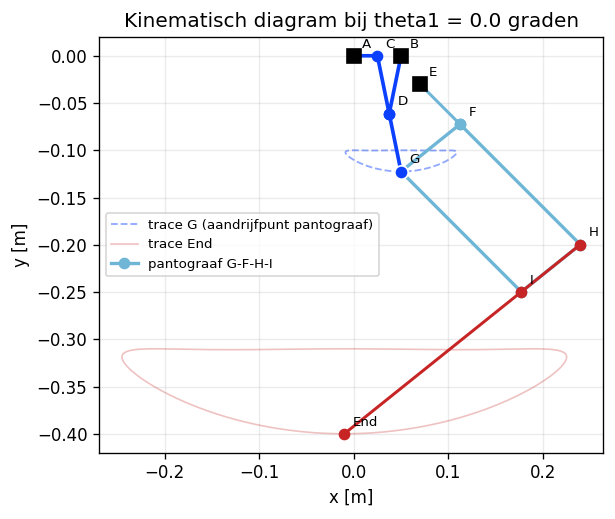

In [12]:
def plot_pose(k, ax=None, show_labels=True, title=None, show_traces=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    p = poses[k]

    blue = '#0b40ff'
    light = '#6fb6d6'
    output = '#c72525'

    if show_traces:
        ax.plot(G_path[:, 0], G_path[:, 1], '--', color=blue, lw=1.1, alpha=0.45,
                label='trace G (aandrijfpunt pantograaf)')
        ax.plot(End_path[:, 0], End_path[:, 1], '-', color=output, lw=1.0, alpha=0.28,
                label='trace End')

    # Chebyshev-deel, zoals in de schets.
    ax.plot([p['A'][0], p['C'][0], p['D'][0], p['B'][0]],
            [p['A'][1], p['C'][1], p['D'][1], p['B'][1]], 'o-', color=blue, lw=2.2)
    ax.plot([p['D'][0], p['G'][0]], [p['D'][1], p['G'][1]], 'o-', color=blue, lw=2.2)

    # E-F is de arm van het vaste pantograafscharnier.
    ax.plot([p['E'][0], p['F'][0]], [p['E'][1], p['F'][1]], 'o-', color=light, lw=1.8)

    # Echte pantograaf: gesloten parallellogram G-F-H-I.
    ax.plot([p['G'][0], p['F'][0], p['H'][0], p['I'][0], p['G'][0]],
            [p['G'][1], p['F'][1], p['H'][1], p['I'][1], p['G'][1]],
            'o-', color=light, lw=2.0, label='pantograaf G-F-H-I')

    # Uitgaande arm volgens Manou-topologie.
    ax.plot([p['End'][0], p['I'][0], p['H'][0]], [p['End'][1], p['I'][1], p['H'][1]],
            'o-', color=output, lw=1.8)

    # Vaste punten.
    fixed = np.vstack([p['A'], p['B'], p['E']])
    ax.plot(fixed[:, 0], fixed[:, 1], 'ks', ms=8)

    # G extra markeren omdat dit het koppelpunt Chebyshev -> pantograaf is.
    ax.plot(p['G'][0], p['G'][1], 'o', color=blue, ms=8, markeredgecolor='white', zorder=6)

    if show_labels:
        for name in point_names:
            ax.annotate(name, p[name], xytext=(5, 5), textcoords='offset points', fontsize=8)

    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    if title:
        ax.set_title(title)
    if show_traces:
        ax.legend(loc='best', fontsize=8)
    return ax

# Pose gekozen zodat de schets goed herkenbaar is: kruk schuin links naar beneden.
# k_demo = int(np.argmin(np.abs(theta1 - np.deg2rad(220))))
k_demo = int(np.argmin(np.abs(theta1 - np.deg2rad(0))))
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_pose(k_demo, ax=ax, title=f'Kinematisch diagram bij theta1 = {np.rad2deg(theta1[k_demo]):.1f} graden')
plt.show()

## 5. Traject van het aandrijfpunt en het eindpunt

`G` is het punt dat de Chebyshev-linkage vastmaakt aan de pantograaf. Daarom plotten we de trace van `G` expliciet naast de trace van `End`.

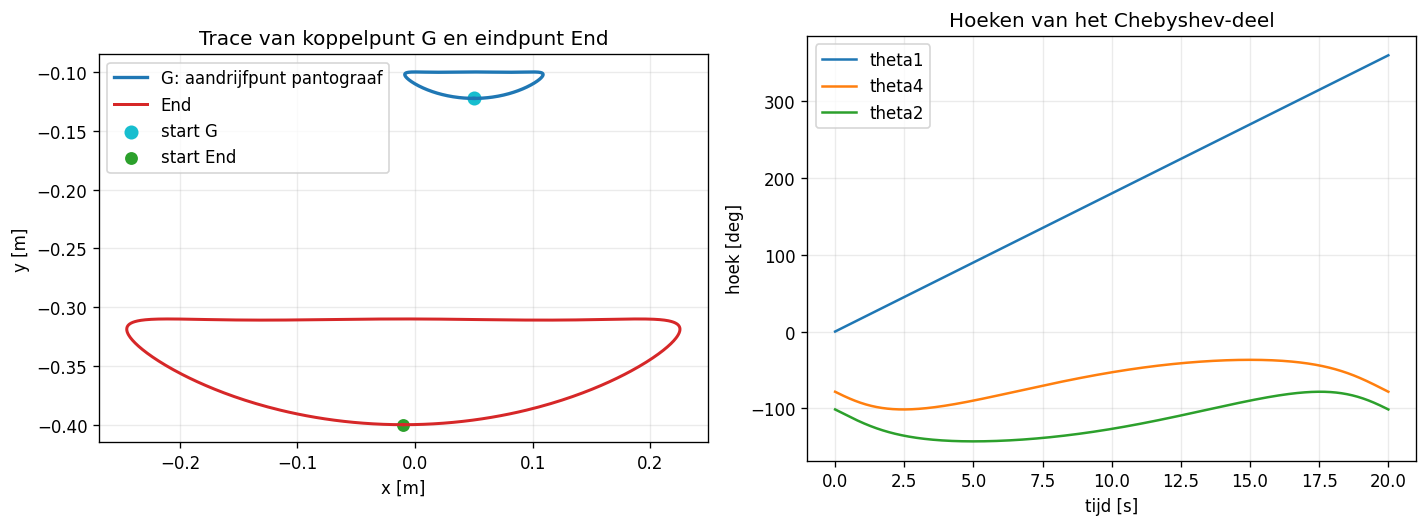

Trajectmaten
G horizontale slag   = 0.1176 m
G verticale slag     = 0.0225 m
End horizontale slag = 0.4704 m
End verticale slag   = 0.0899 m


In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

axs[0].plot(G_path[:, 0], G_path[:, 1], color='tab:blue', lw=2.0, label='G: aandrijfpunt pantograaf')
axs[0].plot(End_path[:, 0], End_path[:, 1], color='tab:red', lw=1.8, label='End')
axs[0].scatter(G_path[0, 0], G_path[0, 1], color='tab:cyan', s=55, label='start G')
axs[0].scatter(End_path[0, 0], End_path[0, 1], color='tab:green', s=45, label='start End')
axs[0].set_aspect('equal', adjustable='box')
axs[0].grid(True, alpha=0.25)
axs[0].set_title('Trace van koppelpunt G en eindpunt End')
axs[0].set_xlabel('x [m]')
axs[0].set_ylabel('y [m]')
axs[0].legend()

axs[1].plot(t, np.rad2deg(thetas[:, 0]), label='theta1')
axs[1].plot(t, np.rad2deg(thetas[:, 3]), label='theta4')
axs[1].plot(t, np.rad2deg(thetas[:, 1]), label='theta2')
axs[1].grid(True, alpha=0.25)
axs[1].set_title('Hoeken van het Chebyshev-deel')
axs[1].set_xlabel('tijd [s]')
axs[1].set_ylabel('hoek [deg]')
axs[1].legend()

plt.tight_layout()
plt.show()

print('Trajectmaten')
print(f'G horizontale slag   = {G_path[:,0].ptp():.4f} m')
print(f'G verticale slag     = {G_path[:,1].ptp():.4f} m')
print(f'End horizontale slag = {End_path[:,0].ptp():.4f} m')
print(f'End verticale slag   = {End_path[:,1].ptp():.4f} m')

## 6. Animatie

Deze cel is optioneel. Ze toont expliciet dat de kleine kruk volledig rondgaat.

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
all_points = np.vstack([P[name] for name in point_names])
pad = 0.06
ax.set_xlim(all_points[:, 0].min() - pad, all_points[:, 0].max() + pad)
ax.set_ylim(all_points[:, 1].min() - pad, all_points[:, 1].max() + pad)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.25)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

def draw_frame(k):
    ax.cla()
    ax.set_xlim(all_points[:, 0].min() - pad, all_points[:, 0].max() + pad)
    ax.set_ylim(all_points[:, 1].min() - pad, all_points[:, 1].max() + pad)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    plot_pose(k, ax=ax, show_labels=False, show_traces=False,
              title=f'theta1 = {np.rad2deg(theta1[k]) % 360:.1f} graden')
    ax.plot(G_path[:k+1, 0], G_path[:k+1, 1], color='tab:blue', alpha=0.65, lw=1.5,
            label='trace G')
    ax.plot(End_path[:k+1, 0], End_path[:k+1, 1], color='tab:red', alpha=0.45, lw=1.0,
            label='trace End')
    ax.legend(loc='best', fontsize=8)

frame_ids = np.arange(0, n_steps, 6)
ani = FuncAnimation(fig, draw_frame, frames=frame_ids, interval=35)
plt.close(fig)
HTML(ani.to_jshtml())